In [1]:
!pip install shap lime xgboost

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7840226b4913d9b00d5eac8c79eee4d2e6edb9508239de4476b472b1ac100e7b
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import shap
from lime import lime_tabular

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
from google.colab import files

print("Please upload the 'smart_manufacturing_energy_metrics.csv' file:")
uploaded = files.upload()

# Get the filename from the uploaded dictionary
for fn in uploaded.keys():
    uploaded_filename = fn
    print(f'User uploaded file "{uploaded_filename}" with length {len(uploaded[fn])} bytes')


Please upload the 'smart_manufacturing_energy_metrics.csv' file:


Saving manufacturing_data (1).csv to manufacturing_data (1).csv
User uploaded file "manufacturing_data (1).csv" with length 109593 bytes


In [8]:
# Read the uploaded CSV file into a DataFrame
df = pd.read_csv(uploaded_filename)

# Display the first 5 rows and information
print(df.head())
print(df.info())


             Timestamp Machine_ID  Power_Consumption (kW)  \
0  2025-04-01 10:00:00       M004               21.767887   
1  2025-04-01 10:01:00       M004               15.514638   
2  2025-04-01 10:02:00       M005               22.353326   
3  2025-04-01 10:03:00       M001               14.808580   
4  2025-04-01 10:04:00       M002               14.253878   

   Production_Rate (units/hr)  Temperature (°C)  Humidity (%)  \
0                         260         29.662881     48.915858   
1                         297         21.982772     52.205069   
2                         191         20.738272     51.706453   
3                         252         24.152850     47.540528   
4                         234         20.482471     58.566706   

  Maintenance_Status  Energy_Efficiency (%)  
0             Normal              76.812182  
1             Normal              86.472287  
2             Normal              81.131523  
3             Normal              77.820295  
4           

In [9]:
# Remove missing values

df = df.dropna()

# Encode categorical columns

le = LabelEncoder()

for col in df.columns:

    if df[col].dtype == 'object':

        df[col] = le.fit_transform(df[col])

print(df.head())

   Timestamp  Machine_ID  Power_Consumption (kW)  Production_Rate (units/hr)  \
0          0           3               21.767887                         260   
1          1           3               15.514638                         297   
2          2           4               22.353326                         191   
3          3           0               14.808580                         252   
4          4           1               14.253878                         234   

   Temperature (°C)  Humidity (%)  Maintenance_Status  Energy_Efficiency (%)  
0         29.662881     48.915858                   1              76.812182  
1         21.982772     52.205069                   1              86.472287  
2         20.738272     51.706453                   1              81.131523  
3         24.152850     47.540528                   1              77.820295  
4         20.482471     58.566706                   1              79.335610  


In [11]:
# Define features and target

X = df.drop("Power_Consumption (kW)", axis=1)

y = df["Power_Consumption (kW)"]

# Train-test split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42
)

# Standardization

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


In [12]:
rf_model = RandomForestRegressor(

    n_estimators=200,
    max_depth=15,
    random_state=42
)

# Train model

rf_model.fit(X_train, y_train)

# Predictions

y_pred = rf_model.predict(X_test)

In [13]:
# Model evaluation

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)

print("RMSE:", rmse)

print("R2 Score:", r2)

MAE: 3.5207589054984316
RMSE: 4.152623577384208
R2 Score: 0.033096526625943756


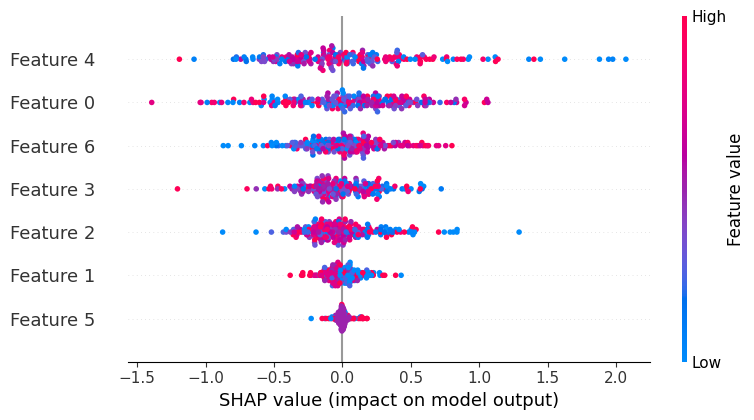

In [14]:
# SHAP analysis

explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test)

# SHAP summary plot

shap.summary_plot(shap_values, X_test)

In [15]:
# LIME explainer

lime_explainer = lime_tabular.LimeTabularExplainer(

    training_data=X_train,

    mode='regression',

    feature_names=X.columns
)

# Explain one prediction

exp = lime_explainer.explain_instance(

    X_test[0],

    rf_model.predict
)

# Show explanation

exp.show_in_notebook(show_table=True)

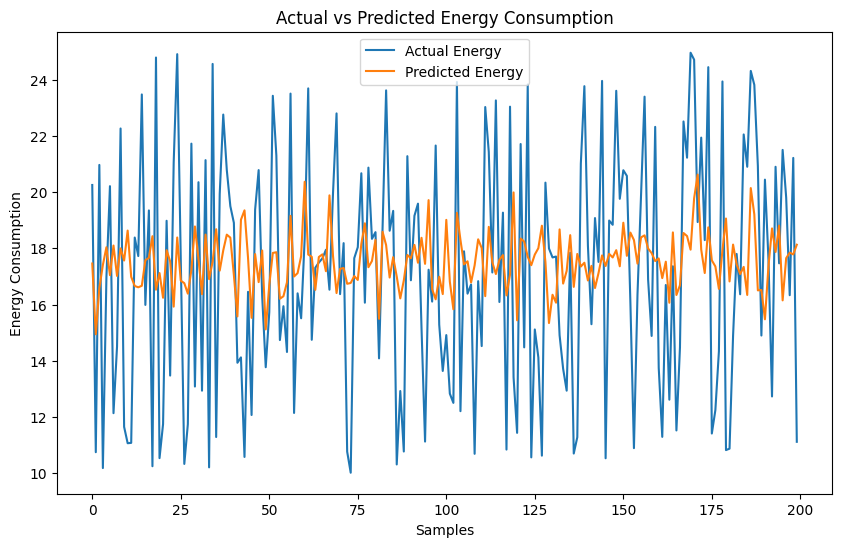

In [16]:
plt.figure(figsize=(10,6))

plt.plot(
    y_test.values,
    label='Actual Energy'
)

plt.plot(
    y_pred,
    label='Predicted Energy'
)

plt.xlabel("Samples")

plt.ylabel("Energy Consumption")

plt.title("Actual vs Predicted Energy Consumption")

plt.legend()

plt.show()